# Deep Learning: III. Transformers and Large Language Models

*Davide Gerosa (Milano-Bicocca)* 

##### Reading/watching

- [Attention Is All You Need](https://arxiv.org/abs/1706.03762), Vaswani et al. (2017). This is *the* transformer paper.
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/), by Jay Alammar. Very visual and highly recommended.
- [The Annotated Transformer](http://nlp.seas.harvard.edu/annotated-transformer/), by Rush. This one is closer to the code.
- [Large Language Models explained briefly](https://www.youtube.com/watch?v=LPZh9BOjkQs), 3Blue1Brown

##### Dig deeper:

- [Hugging Face course](https://huggingface.co/learn/nlp-course/chapter1/1). Practical introduction to using transformer models.
- [Andrej Karpathy's neural networks zero-to-hero](https://karpathy.ai/zero-to-hero.html), especially the language-model videos.
- [Devlin et al. 2018, BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [Radford et al. 2019, Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- [Brown et al. 2020, Language Models are Few-Shot Learners](https://arxiv.org/abs/2005.14165)
- [Dosovitskiy et al. 2020, An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929)
- [Lewis et al. 2020, Retrieval-Augmented Generation](https://arxiv.org/abs/2005.11401)
- [Kaplan et al. 2020, Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361)
- [Hoffmann et al. 2022, Training Compute-Optimal Large Language Models](https://arxiv.org/abs/2203.15556)
- [Bommasani et al. 2021, On the Opportunities and Risks of Foundation Models](https://arxiv.org/abs/2108.07258)
- [Wei et al. 2022, Chain-of-Thought Prompting](https://arxiv.org/abs/2201.11903)


This course is based on previous work by many people. See [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/README.md) for credits.

---

What is the mathematical object inside ChatGPT, Gemini, Claude and the other large language models we now use every day?

The short answer is:

> **An LLM is a very large neural network, usually built from transformer blocks, trained to predict tokens.**

That is both underwhelming and absolutely wild. Let's unpack it.

## From sequences to attention <a class="anchor" id="one"></a>

A lot of data are naturally sequential: the most obvious examples are words in a text. But what is software if now a sequence of symbols?

But also in physics and astronomy: spectra as a function of wavelength, light curves as a function of time, gravitational-wave strain as a function of time.

Before transformers, the standard deep-learning approach for sequences was to use recurrent neural networks (RNNs). These read the sequence from left to right and carry along a hidden state. That sounds natural, but it has two problems:

1. The computation is hard to parallelize because token $t$ depends on token $t-1$.
2. Long-range dependencies are fragile. The model has to remember information through many steps.

Transformers made a very different move: instead of marching through the sequence, let every token look at every other token directly.

This is from the paper that started it all.

!![attention.jpg](https://nlp.seas.harvard.edu/images/ModalNet-21.png)

Credit: [Vaswani et al. 2017](https://arxiv.org/abs/1706.03762).

## Tokens <a class="anchor" id="two"></a>

Language models do not usually predict words. They predict **tokens**.

A token can be a word, a piece of a word, punctuation, whitespace, or some other learned text fragment. For example, a tokenizer might split

> `gravitational-wave astronomy is fun`

into something like

> `gravitational`, `-`, `wave`, ` astronomy`, ` is`, ` fun`

The exact split depends on the tokenizer. This matters more than one might expect. If your favourite astrophysical acronym, source name, or equation-like string is rare in the training set, it may be chopped into awkward pieces.

The first neural-network layer maps each token id to an **embedding vector**. The model no longer sees words; it sees points in a high-dimensional vector space.

$$
\mathrm{token\ id} \longrightarrow \mathbf{x}_i \in \mathbb{R}^{d_{\rm model}}.
$$

The hope is that useful semantic and syntactic structure becomes maths. Tokens used in similar contexts end up with related vectors.

In [1]:
# A tiny, deliberately silly tokenizer example.
# Real tokenizers are learned from large corpora; this is just to fix ideas.

text = "black holes merge after stars evolve"
print(text.split())

vocabulary = {token: i for i, token in enumerate(sorted(set(text.split())))}
print(vocabulary)

ids = [vocabulary[token] for token in text.split()]
print(ids)

['black', 'holes', 'merge', 'after', 'stars', 'evolve']
{'after': 0, 'black': 1, 'evolve': 2, 'holes': 3, 'merge': 4, 'stars': 5}
[1, 3, 4, 0, 5, 2]


## Self-attention <a class="anchor" id="three"></a>

The central operation in a transformer is **self-attention**. The name is good: each token asks, "which other tokens in this same sequence should I pay attention to?"

For each token embedding $\mathbf{x}_i$, the model constructs three vectors:

$$
\mathbf{q}_i = W_Q \mathbf{x}_i, \qquad
\mathbf{k}_i = W_K \mathbf{x}_i, \qquad
\mathbf{v}_i = W_V \mathbf{x}_i.
$$

These are called **queries**, **keys**, and **values**. The terminology comes from databases:

- the query is what a token is looking for,
- the keys say what each token can offer,
- the values contain the information that will be mixed together.

For token $i$, the attention paid to token $j$ is proportional to the dot product between $\mathbf{q}_i$ and $\mathbf{k}_j$:

$$
\mathrm{score}_{ij} = \frac{\mathbf{q}_i \cdot \mathbf{k}_j}{\sqrt{d_k}}.
$$

Then we apply a softmax to convert scores into weights:

$$
\alpha_{ij} = \frac{\exp(\mathrm{score}_{ij})}{\sum_j \exp(\mathrm{score}_{ij})}.
$$

The output for token $i$ is a weighted sum of value vectors:

$$
\mathbf{z}_i = \sum_j \alpha_{ij}\mathbf{v}_j.
$$

In matrix form, the whole operation is

$$
\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V.
$$

That equation is the heart of the transformer. Beautiful, dangerous, and mostly matrix multiplication.

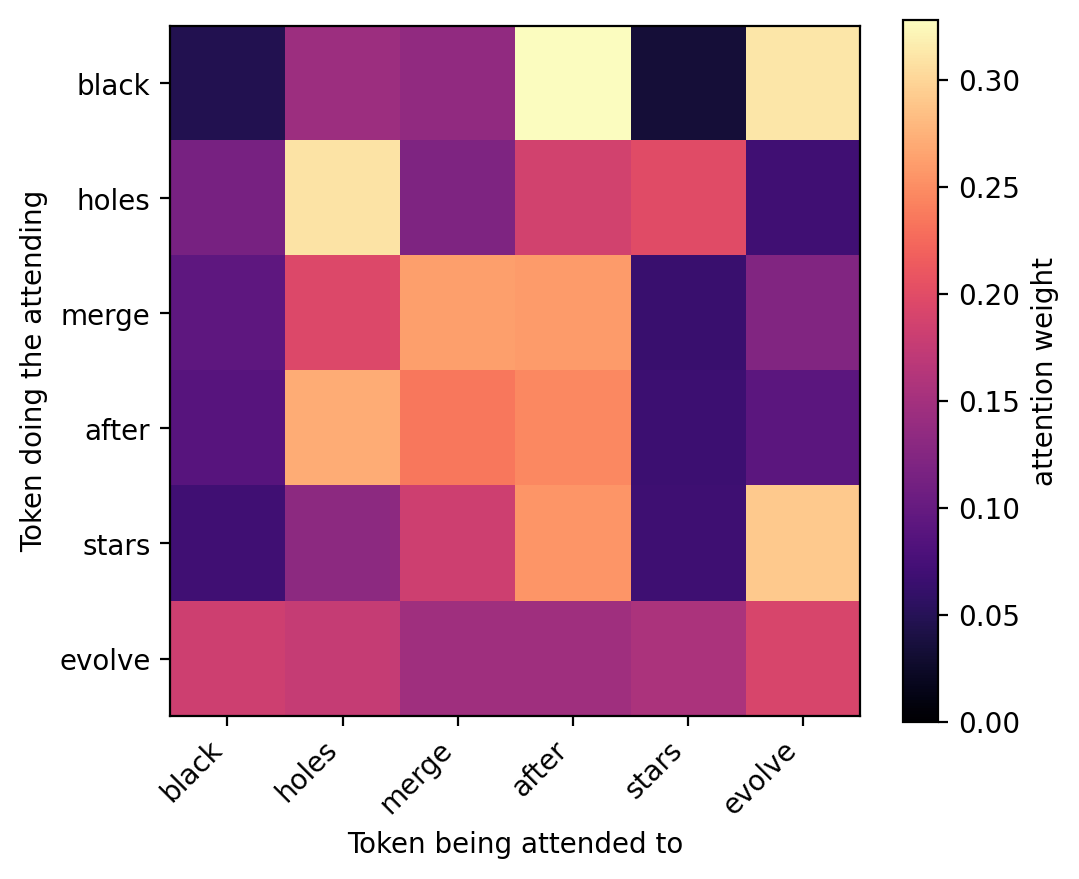

In [2]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

rng = np.random.default_rng(42)

tokens = ["black", "holes", "merge", "after", "stars", "evolve"]
n_tokens = len(tokens)
d_model = 8
d_k = 8

# Fake embeddings and fake learned matrices.
X = rng.normal(size=(n_tokens, d_model))
Wq = rng.normal(scale=0.4, size=(d_model, d_k))
Wk = rng.normal(scale=0.4, size=(d_model, d_k))
Wv = rng.normal(scale=0.4, size=(d_model, d_k))

Q = X @ Wq
K = X @ Wk
V = X @ Wv

scores = Q @ K.T / np.sqrt(d_k)
attention = np.exp(scores - scores.max(axis=1, keepdims=True))
attention = attention / attention.sum(axis=1, keepdims=True)
Z = attention @ V

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(attention, cmap="magma", vmin=0, vmax=attention.max())
ax.set_xticks(range(n_tokens), tokens, rotation=45, ha="right")
ax.set_yticks(range(n_tokens), tokens)
ax.set_xlabel("Token being attended to")
ax.set_ylabel("Token doing the attending")
fig.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

The plot above is just random weights, so do not overinterpret it. But it shows the object we care about: an $N_{\rm tokens}\times N_{\rm tokens}$ attention matrix.

In a trained model, different layers and different attention heads learn different patterns. Some heads track nearby syntax. Some connect a pronoun to a noun. Some identify list structure. Some may be doing things that are much less human-legible.

This is one reason interpretability is tricky: the attention weights are tempting to look at, but they are not automatically an explanation of the model's answer.

## Multi-head attention <a class="anchor" id="four"></a>

One attention operation is useful, but limited. A transformer uses **multi-head attention**: several attention maps are computed in parallel, each with its own learned $W_Q$, $W_K$, and $W_V$ matrices.

![Multi-head attention](https://jalammar.github.io/images/t/transformer_multi-headed_self-attention-recap.png)

Credit: [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/), Jay Alammar.

The outputs are concatenated and mixed again with another linear layer. Intuitively, the model gets several ways of asking "what matters here?" at once.

In astronomy language, I think of this like measuring the same object through several filters.

## Positional encodings <a class="anchor" id="five"></a>

There is a subtle issue. Self-attention by itself does not know the order of the tokens. If we permute the input tokens, the same pairwise dot products are still available, just permuted.

But order matters:

- `stars eat planets` is not the same as `planets eat stars`,
- a time series shuffled randomly is usually destroyed,
- code with lines out of order is a deeply unpleasant object.

Transformers therefore add **positional information** to token embeddings. The original paper used sinusoidal positional encodings:

$$
\mathrm{PE}_{(\mathrm{pos},2i)} = \sin\left(\frac{\mathrm{pos}}{10000^{2i/d_{\rm model}}}\right),
$$

$$
\mathrm{PE}_{(\mathrm{pos},2i+1)} = \cos\left(\frac{\mathrm{pos}}{10000^{2i/d_{\rm model}}}\right).
$$

Many modern models use learned positional embeddings, rotary position embeddings, or other variants. The basic need is the same: give the model a coordinate system along the sequence.

## GPTs (Generative pre-trained transformer) <a class="anchor" id="six"></a>

A GPT-style model is trained autoregressively. Given tokens

$$
x_1, x_2, \ldots, x_t,
$$

it predicts

$$
p(x_{t+1}\mid x_1, x_2, \ldots, x_t).
$$

That means the model is trained on a brutally simple task: guess the next token. The shock is that, at very large scale, next-token prediction appears to force the model to learn a great deal about syntax, facts, style, code, and pieces of reasoning.

![A decoder-only transformer generates one token at a time](https://jalammar.github.io/images/xlnet/gpt-2-autoregression-2.gif)

Credit: [The Illustrated GPT-2](https://jalammar.github.io/illustrated-gpt2/), Jay Alammar.

There is an important trick. During training, the answer token is already in the sequence. We must prevent the model from cheating by looking into the future.

So we use a **causal mask**. Token $i$ can attend only to tokens $j\le i$.

Mathematically, we add $-\infty$ to the forbidden attention scores before the softmax:

$$
\mathrm{score}_{ij} = -\infty \quad \mathrm{for}\quad j>i.
$$

After the softmax, those future-token weights become exactly zero.

## Training an LLM <a class="anchor" id="eight"></a>

Training has several stages:

1. **Pretraining.** Train on a huge corpus to predict the next token. This is where most of the compute goes.
2. **Instruction tuning.** Fine-tune on examples of useful instructions and answers.
3. **Preference optimization.** Tune the model so that humans, or another model standing in for humans, prefer its answers.
4. **Tool use and retrieval.** Connect the model to search, code execution, documents, databases, or other tools.

The base model learns language. The later stages make it behave like an assistant.

This distinction matters. A base model is not trying to be correct or helpful; it is trying to continue text. A chat model has been trained to answer in a more useful way, but it is still built on top of the next-token machine.

Scaling laws are one reason this field moved so quickly: for a while, making models larger, feeding them more data, and using more compute gave fairly predictable improvements. See for instance [Kaplan et al. (2020)](https://arxiv.org/abs/2001.08361) and [Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556). Reality is now messier and much more expensive, but the basic lesson remains important.

## Why do LLMs hallucinate? <a class="anchor" id="nine"></a>

A language model does not store a bibliography database and retrieve from it by default. It samples likely continuations from a learned distribution.

That means it can produce text that is:

- grammatical,
- confident,
- stylistically plausible,
- and false.

This is not a weird bug. It follows from the training objective. If the model has seen many paper titles, author lists, BibTeX entries, and arXiv-like strings, it can generate something that looks exactly like a citation. Looking like a citation and being a real citation are different tasks.

For scientific work, the rule is simple:

> **Use LLMs for acceleration, not authority.**

Good uses:

- explain a method at a different level,
- draft code you will test,
- summarize papers you provide explicitly,
- translate between notation systems,
- brainstorm checks, caveats, and edge cases.

Dangerous uses:

- cite papers without verifying them,
- trust numerical claims without checking sources,
- paste private data into external systems,
- let the model silently choose your statistical assumptions.

Actually, tyhis is the same lesson as the rest of this course: get data, adopt a model, validate the output.

## Prompting <a class="anchor" id="twelve"></a>

A prompt is not a spell. It is the interface between your scientific intent and the model's conditional distribution.

Good prompts usually specify:

- the task,
- the context,
- the expected format,
- constraints,
- what sources or data should be used,
- what uncertainty should be reported.

For example, this is weak:

> Explain nested sampling.

This is stronger:

> Explain nested sampling to a first-year physics MSc student who knows MCMC and Bayesian evidence but has not seen live points. Use equations for the evidence integral and include two failure modes relevant to multimodal posteriors.

For coding, ask for tests. For literature, ask for citations and then verify them. For statistics, ask the model to state assumptions explicitly.

### A mini-GPT trained on these lectures

This doesn't really work, but I tried to train a real transformer language model (but make it small enough that it can run on this laptop during class). More on this: https://github.com/karpathy/nanogpt

I'm training this models on the markdown text from the lecture notebooks in this class. The hope is that this gives the model the vocabulary and rhythm of this course.

This is absolutely minuscule compared to a real LLM, but the ingredients are the same:

- learned token embeddings,
- learned positional embeddings,
- causal self-attention,
- transformer blocks,
- next-token prediction,
- sampling with temperature and top-k filtering.

On a normal laptop this should take a few minutes. If it is too slow, reduce `max_iters` first.

In [3]:
# A small GPT-like word-level model trained on the lecture notebooks themselves.
# This follows the spirit of Andrej Karpathy's nanoGPT examples.

import json
import re
import time
from collections import Counter
from pathlib import Path

import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(42)


def find_lecture_notebooks():
    paths = sorted(Path("lectures").glob("L*.ipynb"))
    if not paths:
        paths = sorted(Path(".").glob("L*.ipynb"))
    if not paths:
        paths = sorted(Path("extra").glob("L*.ipynb"))
    return paths

texts = []
for path in find_lecture_notebooks():
    try:
        nb = json.loads(path.read_text())
    except Exception:
        continue
    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "markdown":
            texts.append("".join(cell.get("source", [])))

# Fallback, useful if this cell is copied outside the repository.
if not texts:
    texts = ["""
    Astronomy data include images, spectra, light curves, catalogs, and gravitational waves.
    Bayesian inference combines likelihoods and priors to obtain posterior distributions.
    Neural networks learn flexible models from examples, but validation is essential.
    Transformers use attention to predict the next token in a sequence.
    """]

raw_text = "\n".join(texts).lower()
raw_text = re.sub(r"https?://\S+", " URL ", raw_text)
raw_text = re.sub(r"`+", " ", raw_text)

# A deliberately simple tokenizer: words, numbers, and individual punctuation marks.
token_pattern = re.compile(r"[a-z]+(?:'[a-z]+)?|[0-9]+(?:\.[0-9]+)?|[^\w\s]", re.IGNORECASE)
tokens = token_pattern.findall(raw_text)

# Keep the common vocabulary. Rare tokens are mapped to <unk>.
max_vocab = 3000
counts = Counter(tokens)
vocab = ["<unk>"] + [tok for tok, _ in counts.most_common(max_vocab - 1)]
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

def encode(s):
    return [stoi.get(tok, 0) for tok in token_pattern.findall(s.lower())]

def decode(ids):
    text = " ".join(itos[int(i)] for i in ids)
    text = re.sub(r"\s+([,.;:?!%)\]])", r"\1", text)
    text = re.sub(r"([(\[])\s+", r"\1", text)
    text = re.sub(r"\s+'\s+", "'", text)
    return text

data = torch.tensor([stoi.get(tok, 0) for tok in tokens], dtype=torch.long)
print(f"{len(tokens):,} training tokens")
print(f"{len(vocab):,} token vocabulary")
print("sample tokens:", tokens[1400:1430])

118,766 training tokens
3,000 token vocabulary
sample tokens: ['(', 'URL', 'will', 'be', 'the', 'premier', 'radio', 'observatory', 'of', 'the', 'late', '2020', 's', 'and', '2030', 's', ',', 'consisting', 'of', '~', '3000', 'dishes', ',', 'each', '15', 'meters', 'wide', ',', 'and', 'spread']


In [4]:
# On a laptop, max_iters=1500 is a few minutes.

block_size = 128        # how many previous tokens the model can read
batch_size = 32
n_embd = 192
n_head = 6
n_layer = 6
max_iters = 5000
learning_rate = 1e-3
dropout=0.1

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("training on", device)
data = data.to(device)

def get_batch():
    ix = torch.randint(len(data) - block_size - 1, (batch_size,), device=device)
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

training on mps


In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert n_embd % n_head == 0
        self.key = nn.Linear(n_embd, n_embd, bias=False)
        self.query = nn.Linear(n_embd, n_embd, bias=False)
        self.value = nn.Linear(n_embd, n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        head_size = C // n_head
        k = self.key(x).view(B, T, n_head, head_size).transpose(1, 2)
        q = self.query(x).view(B, T, n_head, head_size).transpose(1, 2)
        v = self.value(x).view(B, T, n_head, head_size).transpose(1, 2)

        wei = q @ k.transpose(-2, -1) * head_size ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa = CausalSelfAttention()
        self.ffwd = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(len(vocab), n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, len(vocab))

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, len(vocab)), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=120, temperature=0.8, top_k=40):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.shape[-1]))
                logits[logits < values[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx

model = MiniGPT().to(device)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

3,845,688 parameters


In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
start = time.time()
losses = []

for step in range(max_iters + 1):
    xb, yb = get_batch()
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses.append(loss.item())

    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss.item():.3f}")

print(f"training time: {time.time() - start:.1f} s")

step    0 | loss 8.189
step  100 | loss 4.403
step  200 | loss 3.753
step  300 | loss 3.649
step  400 | loss 3.118
step  500 | loss 2.897
step  600 | loss 2.553
step  700 | loss 2.233
step  800 | loss 2.222
step  900 | loss 1.763
step 1000 | loss 1.471
step 1100 | loss 1.290
step 1200 | loss 1.192
step 1300 | loss 1.004
step 1400 | loss 0.915
step 1500 | loss 0.785
step 1600 | loss 0.685
step 1700 | loss 0.627
step 1800 | loss 0.555
step 1900 | loss 0.586
step 2000 | loss 0.528
step 2100 | loss 0.473
step 2200 | loss 0.488
step 2300 | loss 0.474
step 2400 | loss 0.418
step 2500 | loss 0.401
step 2600 | loss 0.392
step 2700 | loss 0.377
step 2800 | loss 0.363
step 2900 | loss 0.352
step 3000 | loss 0.333
step 3100 | loss 0.363
step 3200 | loss 0.322
step 3300 | loss 0.317
step 3400 | loss 0.301
step 3500 | loss 0.294
step 3600 | loss 0.286
step 3700 | loss 0.282
step 3800 | loss 0.313
step 3900 | loss 0.286
step 4000 | loss 0.271
step 4100 | loss 0.280
step 4200 | loss 0.257
step 4300 |

In [12]:
for prompt in ["Kernel Density Estimation", "MCMC", "model selection", "Are rhinos better than elephants?"]:
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=100, temperature=0.3, top_k=100)[0].tolist()
    print("\nPROMPT:", prompt)
    print(decode(generated))


PROMPT: Kernel Density Estimation
kernel density estimation is useful because: - <unk> low probability density estimation is tricky: the <unk> within a tricky of the pdf can be defined as $ $ f k = 3 k = 10 $ and $ k = 10 $. this is just as simple: while $ $ p (x 1) = \ sim \ frac { 2 } { 4 } = \ frac { 3 } { n - 1 } } \ frac { n } { n - 1 } \ sigma { \ overline { x } }. $

PROMPT: MCMC
mcmc sampling] (URL # # # # back to the handwritten digits... let's go back to our previous example on the astrophysical transient. 8) fit the same model from before with the same priors, but this time use nested sampling. $ y = b $, for $ t < t 0 $ $ y = b + a \ exp [- \ alpha (t - t 0)] $, for $ t 0 $ be careful with how you transform your parameter space into a unit hypercube

PROMPT: model selection
model selection to? - - # # # <unk> speaking.. almost everything that we will do can be <unk> into one of two different pairs of things. - * * supervised learning * * vs. * * unsupervised learning * * -

This is still not a useful scientific model, but it kind of looks like my course material. The output usually has recognizable phrases, equations-ish punctuation, and topic changes that resemble the lecture notes. It will also still say false or weird things...

Experiments I haven't tried.

- This has not converged. Increase `max_iters`.
- Increasing `n_embd`, `n_layer`, `n_head` makes the model larger.
- Change `temperature` from `0.5` to `1.1`. Low temperature makes the model conservative and repetitive. High temperature makes it more creative, then rapidly more chaotic. 
- Change `top_k` from `10` to `100`. Restrict sampling to likely tokens

## Start from here

- This is a nice introductroy review article [Transformers for scientific data: a pedagogical review for astronomers](https://arxiv.org/abs/2310.12069)
- This [https://github.com/karpathy/nanogpt](https://github.com/karpathy/nanogpt) is an amazing repository. It's a collection of small GPTs  models one can train on a laptopt (or a small cluster such as those of physics department). If you're interested in LLMs, I think it's a great resource. 

## Transformers in astrophysics

Astronomy has also started using transformers: a few entry points.

- [AstroPhot: fitting astronomical images with neural networks](https://arxiv.org/abs/2401.14487)
- [AstroCLIP: cross-modal pre-training for astronomical foundation models](https://arxiv.org/abs/2310.03024)
- [The Well: a large-scale collection of physics simulations for machine learning](https://arxiv.org/abs/2412.00568)
- [Transformers for gravitational-wave detection](https://arxiv.org/abs/2505.02773), with Federico De Santi from our group.

## More astro applications

- [Applying Vision Transformers on Spectral Analysis of Astronomical Objects](https://arxiv.org/abs/2506.00294)
- [Towards an astronomical foundation model for stars with a Transformer-based model](https://arxiv.org/abs/2308.10944)
- [GraviBERT: Transformer-based inference for gravitational-wave time series](https://arxiv.org/abs/2512.21390)
- [ATAT: Astronomical Transformer for time series and Tabular data](https://arxiv.org/abs/2405.03078)
- [AstroCLIP: A Cross-Modal Foundation Model for Galaxies](https://arxiv.org/abs/2310.03024)
- [Can Transformers help us perform parameter estimation of overlapping signals in gravitational wave detectors?
](https://arxiv.org/abs/2505.02773) with Federico De Santi from my research group
- [Flexible Gravitational-Wave Parameter Estimation with Transformers](https://arxiv.org/abs/2512.02968)


### ... and we're done.

I'm not saying that you are ready for a data science job after these two lectures on deep learning, but at leat you know where to start. There are tons of useful videos, tutorials, and online courses that can take you further if you are interested in deep learning.


---

## Does astrophysics still make sense in the LLM era?

I highly reccommend reading this commentary piece by David Hogg (New York University): https://arxiv.org/abs/2602.10181

## My very personal opinion on the AI revolution 
    
AI is revolutionary because of the scale of complexity it reached. If you think about it, even a linear fit is "generative AI", in the sense that you learned something from previous data and can predict on a new unseen instance. But we humans don't find it surprising ("a computer might be faster, but I could do it as well"). LMMs have now reached a level of complexity that is comparable (or beyond actually) to that of our brains. It's the scale of the novelty that is revolutionary, not the novelty itself. Somehow humanity has been writing texts for a millennia, all that text is there and can be reproduced.

For instance: it turns our LMMs are really good at translating between languages. They weren't trained for that, but the information is there in all the text humans have written, and LMMs picked it up. Translating is a challenging task for a human (how many languages do you know?); that's what I mean by the scale of complexity.       

---

# Ideas for Master's thesis projects with me and my research group

- **Theory** of black-hole binaries, post-Newtonian approximation to General Relativity, gauge effects in gravity, spin-orbit interactions.
- **Astrophysics** of gravitational-wave sources (how do merging black holes and neutron stars form from their stellar progenitors?)
- **Data analysis** of gravitational-wave detectors, both for single events and population of sources. Across detectors: LIGO/Virgo today, Einstein Telescope and LISA tomorrow.  
- ...all of this with or without some statistics and machine learning.

More on my research group here: https://davidegerosa.com/group/

Here is some work from MSc thesis projects I supervised that ended up in published papers:
- Alessia Corelli (just graduated): https://arxiv.org/abs/2603.00239
- Giovanni Giarda (then PhD at ETH Zurich): https://arxiv.org/abs/2506.12572
- Cecilia Fabbri (then PhD in Nottingham, UK): https://arxiv.org/abs/2501.17233
- Alessandro Pedrotti (then PhD in Marseille): https://arxiv.org/abs/2504.10482
- Francesco Nobili (then PhD in Como, Italy): https://arxiv.org/abs/2504.17021
- Alessandro Santini (then PhD at Max Planck AEI, Germany): https://arxiv.org/abs/2308.12998
- Giovanni Cavallotto (then technician here at Bicocca): https://arxiv.org/abs/2304.04801
- Maciej Dabrowny (then data scientist): https://arxiv.org/abs/2106.12541
- Matteo Boschini (then PhD in my group): https://arxiv.org/abs/2307.03435
- Alice Spadaro (then PhD in my group): https://arxiv.org/abs/2306.03923
- Luca Reali (then PhD at Johns Hopkins, USA): https://arxiv.org/abs/2005.01747
- Riccardo Barbieri (then PhD at Max Planck AEI, Germany): https://arxiv.org/abs/2004.02894

# That's all folks

<div class="alert alert-block alert-warning">
    
<h2 style="margin-top:0;"><strong>Feedback!</strong></h2>

Please help me with this class! I want to make it better. This is a short feedback form:

https://forms.gle/BtwUUGpkWuVFtEwH8

Note this *does not substitute* the acutal university questionnarie, which is more important and enter the class evaluation. This one is just for me so I can be specific on the content of this course. 

**Please do complete the University questionnarie; that is very important!** As we've seen at lenght, we need large datasets to get meaningful conclusions (I guess errors here will go as $\sqrt{N_{\rm students}}$) 

</div>




![](https://imgs.xkcd.com/comics/data_trap.png)

But hopefully now you know what do to with data (at least a bit).